In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv('economic_index.csv')

In [91]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [92]:
#Drop unnecessary columns
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [93]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [94]:
#check Null
df.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


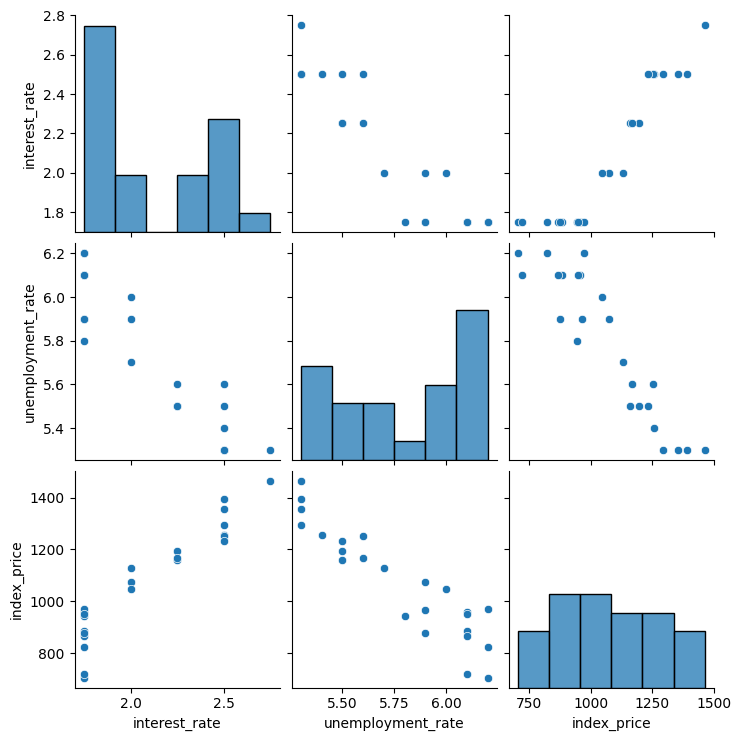

In [95]:
sns.pairplot(df)

In [96]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


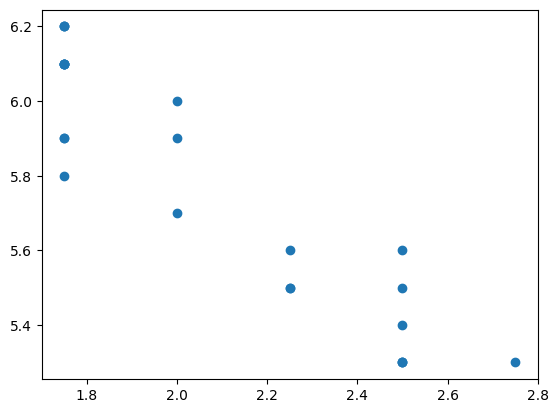

In [97]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])

In [98]:
X = df[['interest_rate','unemployment_rate']]
y = df['index_price']

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

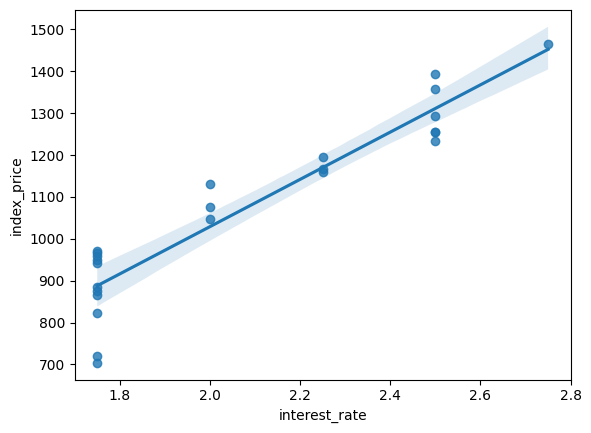

In [101]:
sns.regplot(x=df['interest_rate'],y=df['index_price'])

In [102]:
#standardization
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [103]:
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [104]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [105]:
model.fit(X_train,y_train)

LinearRegression()

In [106]:
# Cross-Validation with sklearn
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [107]:
print("Mean_Validation_Score : ",np.mean(validation_score))

Mean_Validation_Score :  -5914.828180162386


In [108]:
#Prediction
y_pred = model.predict(X_test)

In [110]:
#Performance Metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [113]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"Mean Squared Error : {mse}\nMean Absolute Error : {mae}\nRoot Mean Squared Error : {np.sqrt(mse)}\n\nr2 score : {r2}\nAdjusted r2 score : {1 - (((1-r2)*(len(X_test-1))/(len(X_test)-X_test.shape[1]-1)))}")

Mean Squared Error : 8108.567426306604
Mean Absolute Error : 73.80444932337097
Root Mean Squared Error : 90.04758423359621

r2 score : 0.7591371539010257
Adjusted r2 score : 0.5182743078020513


In [133]:
print("Intercept : ",model.intercept_)
print("Coefficient or Slope : ",model.coef_)

Intercept :  1053.4444444444443
Coefficient or Slope :  [  88.27275507 -116.25716066]


# ***Assumptions***

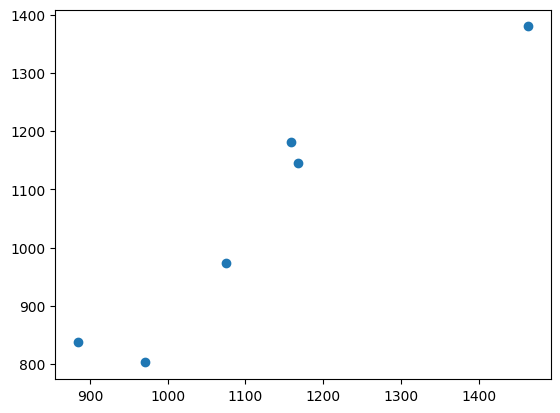

In [114]:
plt.scatter(y_test,y_pred)

In [115]:
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


<Axes: xlabel='index_price', ylabel='Density'>

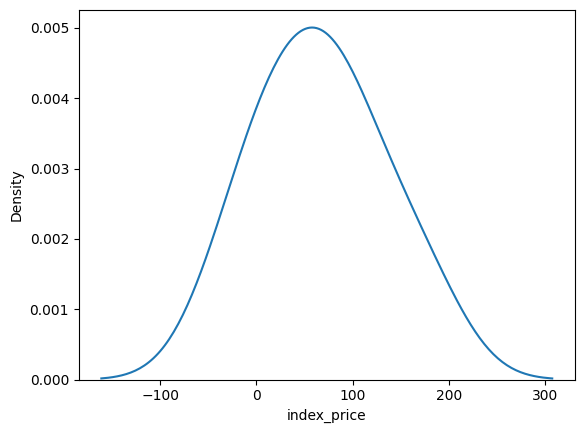

In [126]:
sns.kdeplot(residuals)

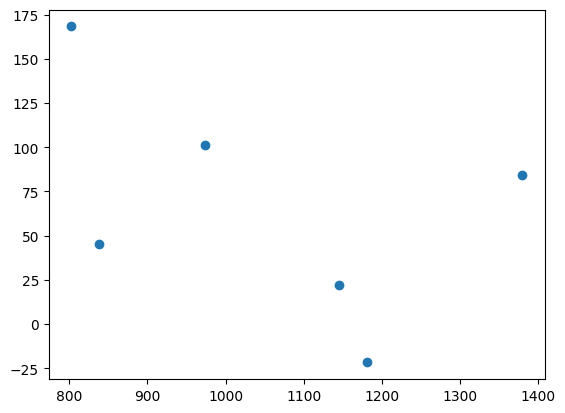

In [127]:
# Scatter plot with residuals and predictions
plt.scatter(y_pred,residuals)

# **OLS**

In [130]:
import statsmodels.api as sm
ols_model = sm.OLS(y_train,X_train).fit()

In [132]:
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 05 Oct 2026   Prob (F-statistic):                       0.754
Time:                        10:34:33   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""